*  Nate Diaz-Santana
*  Data Mining

In [2]:
import pandas as pd
import numpy as np
import seaborn as sb
import matplotlib.pyplot as plt

from dateutil import parser
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge, Lasso

# EDA

In [4]:
data = pd.read_csv("car_prices.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


## Average Selling Price by Year

In this graph, we can see that a lot of the more current year models have a lot of outliers, which I personally believe to be more luxurious brands or better/performance trims driving up the price away from the average for that year. Due to this, I think it's definitely in place to look into possibly encoding brands and models to be able to use them as features as they might help predict prices more accurately.

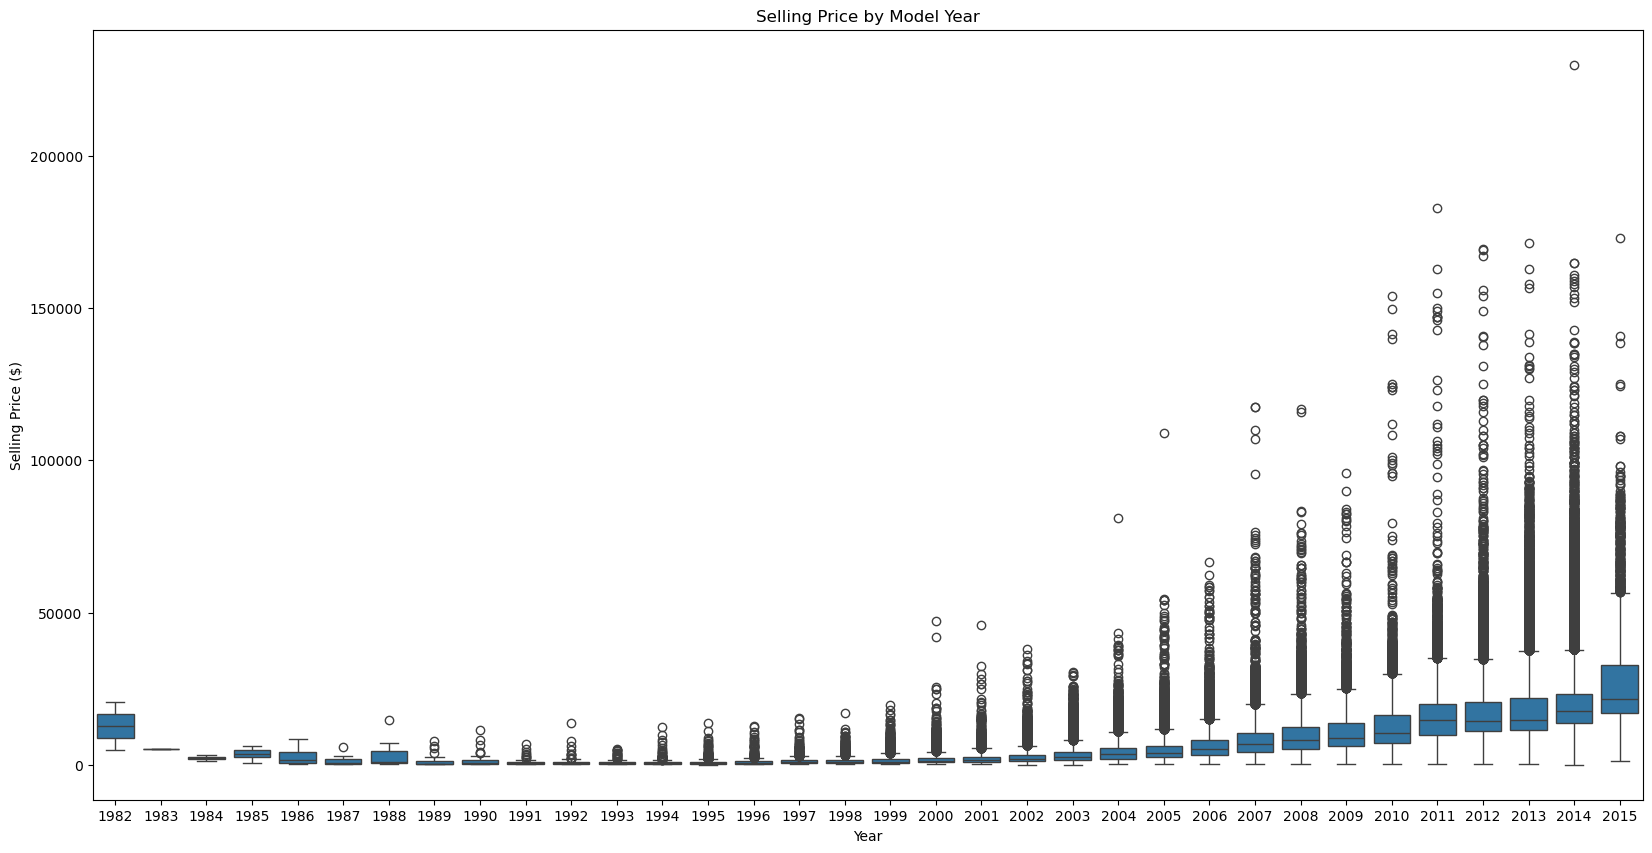

In [7]:
plt.figure(figsize=(20,10))
sb.boxplot(data=data, x='year', y='sellingprice')
plt.title('Selling Price by Model Year')
plt.ylabel('Selling Price ($)')
plt.xlabel('Year')
plt.show()

## Average Selling Price by Condition

In this graph we see that there is a steady rise in condition from 1 through 5, and then a dip from 11 to 19, and then a steady rise from 21 to 49. The way the first 1 through 5 section just drops down makes me think that the cars in this section are probably from a source that used a 1-5 scale for condition while the rest are probably sourced from different sources that either didn't have a condition scale, which might explain the dip between 11 to 19, or used different scales completely, which might explain why the scale max is 49 rather than an even number or something like 100. This is definitely something to look further into, as if they're different scales being used, it might actually hurt the model prediction rather than hurt it, since one source might have a 5 that means a run-down car with a low price, while another might have a 5 that means a brand new car with a high price.

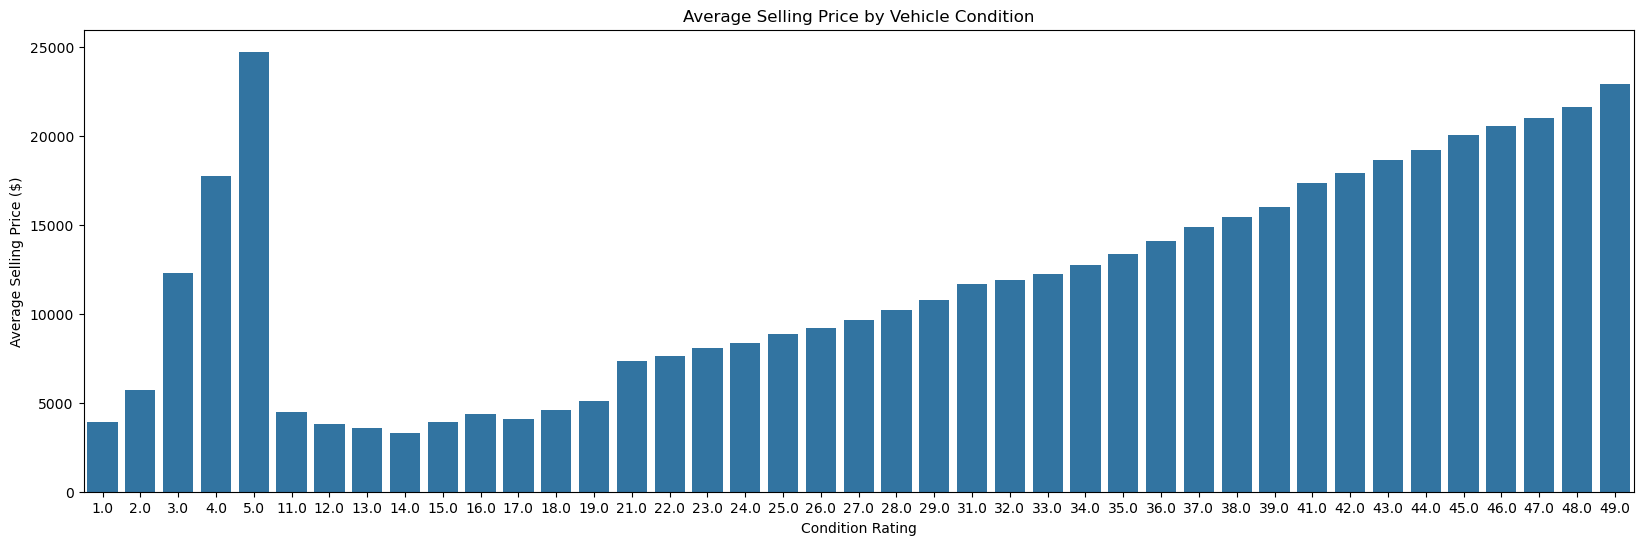

In [10]:
plt.figure(figsize=(20,6))
sb.barplot(data=data, x='condition', y='sellingprice', errorbar=None)
plt.title('Average Selling Price by Vehicle Condition')
plt.xlabel('Condition Rating')
plt.ylabel('Average Selling Price ($)')
plt.show()

## Correlation Heatmap

In this correlation heatmap, we see that the MMR prices tend to be pretty accurate estimates compared to the actual selling prices. We also see that the second most notable correlation is the negative 0.77 correlation between odometer and year, which makes sense as older cars tend to have been used more therefore racking up more miles. Other notable correlations are the ones between MMR and year, and selling price and year. Both of these are 0.59 and 0.58, respectively, which indicated that only about 58% of the price is influenced by the year of car. While it's still more than half the price, I think the lack of stronger correlations in the heatmap indicates that there is definitely a possibility that the price can be greatly affected by one of our non-numeric variables, which further supports by conclusion that these are worth trying to encode into numeric values to be used as part of the model.

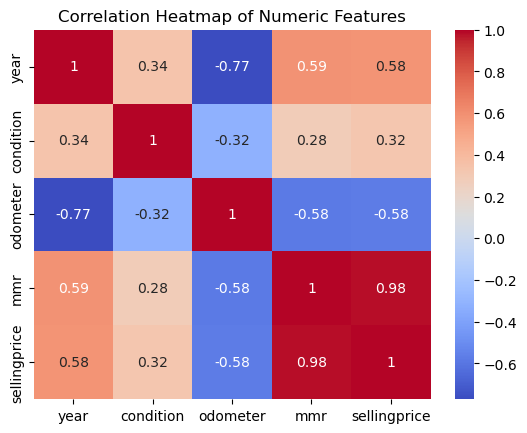

In [13]:
num_feat = ['year', 'condition', 'odometer', 'mmr', 'sellingprice']
num_cols = data[num_feat].dropna()
corr_matrix = num_cols.corr()

sb.heatmap(corr_matrix, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()

## Scatterplot Matrix

In this scatterplot matrix, we see all the numeric variables plotted against each other. Some of the features I found most interesting are the gaps in the condition plots that I previously mentioned and the oddly shaped clusters in the year and condition graphs, the pretty clear line in the MMR and selling price graphs, and the exponential graphs between year and selling price/MMR and MMR/selling price and odometers. I think these graphs definitely help visualize some of the correlations in the above heatmap, as we can more clearly see how the data is plotted between the two variables. 

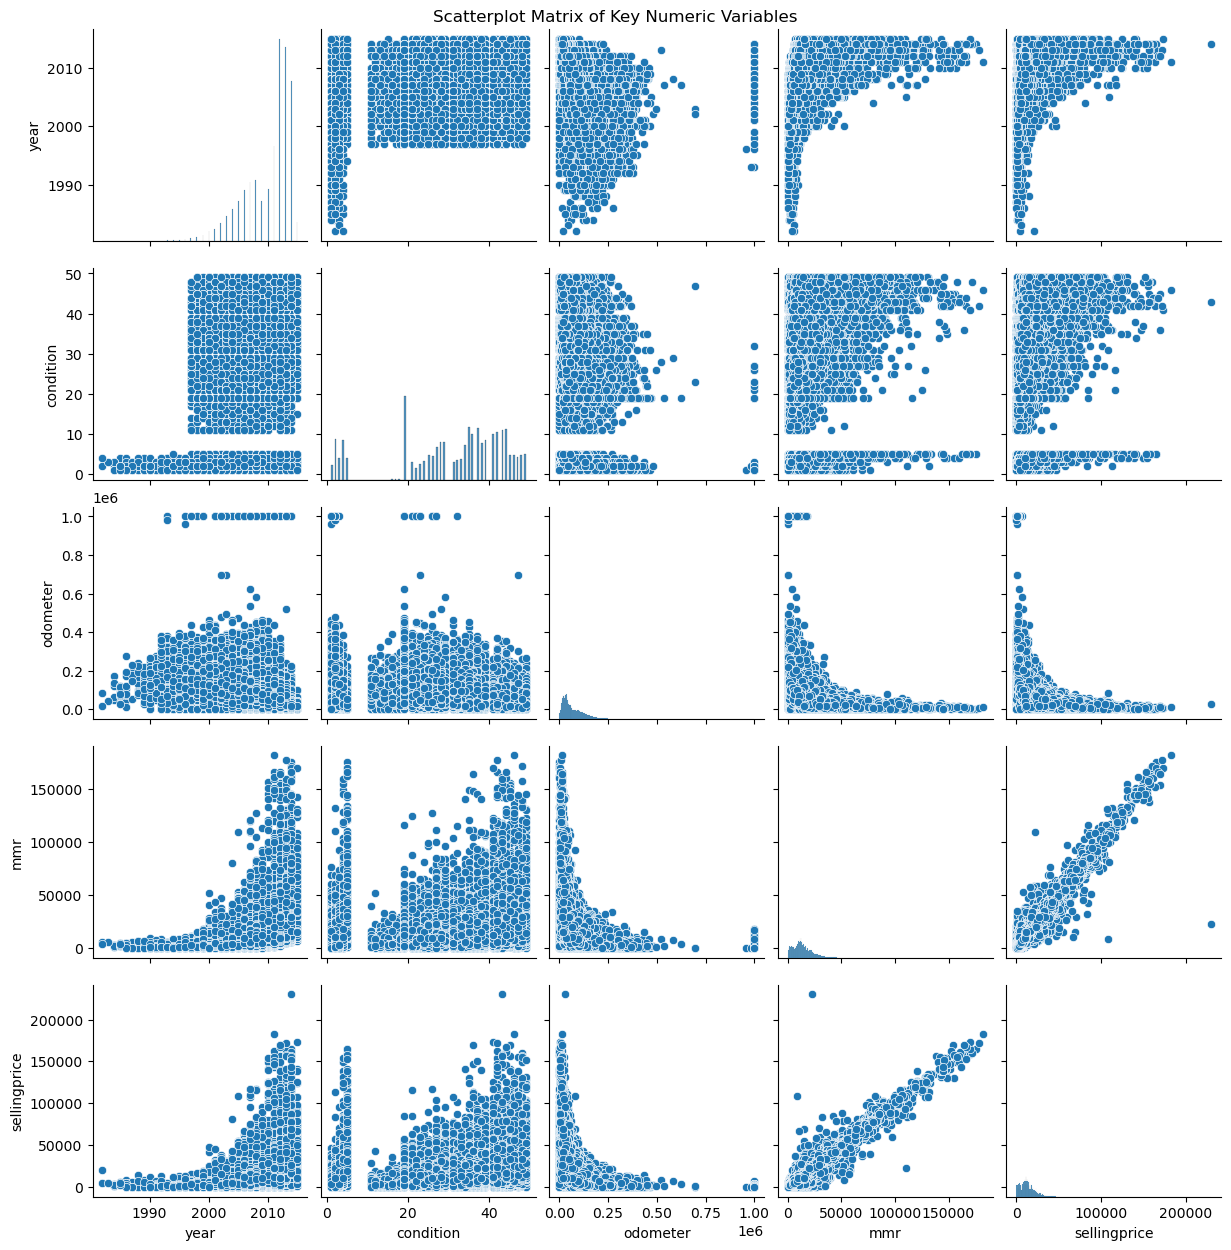

In [16]:
sb.pairplot(num_cols)
plt.suptitle('Scatterplot Matrix of Key Numeric Variables', y=1)
plt.show()

# Data Preparation

In [18]:
data = pd.read_csv("car_prices.csv")
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 558837 entries, 0 to 558836
Data columns (total 16 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558837 non-null  int64  
 1   make          548536 non-null  object 
 2   model         548438 non-null  object 
 3   trim          548186 non-null  object 
 4   body          545642 non-null  object 
 5   transmission  493485 non-null  object 
 6   vin           558833 non-null  object 
 7   state         558837 non-null  object 
 8   condition     547017 non-null  float64
 9   odometer      558743 non-null  float64
 10  color         558088 non-null  object 
 11  interior      558088 non-null  object 
 12  seller        558837 non-null  object 
 13  mmr           558799 non-null  float64
 14  sellingprice  558825 non-null  float64
 15  saledate      558825 non-null  object 
dtypes: float64(4), int64(1), object(11)
memory usage: 68.2+ MB


## Dropping Unnecessary Features

For this step, I'll be dropping the vin and the seller columns becuase the vehicle identification number is unique for every car and doesn't really help us with the model at all, and neither does the seller, at least in this dataset, since it gives the business name of the seller instead of whether the seller is an individual or a car dealer.

Initially, I was also going to drop sale date, but I will be using it for an engineered feature in the coming steps. Another column I considered dropping was the trim but I decided to keep it as I believe the higher end trims can affect the price quite a bit sometimes.

In [22]:
# Drop rows where vin has 'automatic' as a value to drop a few shifted entries
data = data[data['vin'].str.lower() != 'automatic']

In [23]:
data = data.drop(columns=['vin', 'seller'])

We also need to drop the MMR column, as it's already a product of another model predicting price, I intended to include it to help the model with estimation, however the models depended too much on this MMR feature to predict price so I will need to remove it. However, for now, it will stay in the dataset as it needs to be processed since it's used for model comparison later in this project.

In [25]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558815 entries, 0 to 558836
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558815 non-null  int64  
 1   make          548514 non-null  object 
 2   model         548416 non-null  object 
 3   trim          548164 non-null  object 
 4   body          545620 non-null  object 
 5   transmission  493463 non-null  object 
 6   state         558815 non-null  object 
 7   condition     547017 non-null  float64
 8   odometer      558721 non-null  float64
 9   color         558066 non-null  object 
 10  interior      558066 non-null  object 
 11  mmr           558799 non-null  float64
 12  sellingprice  558803 non-null  float64
 13  saledate      558803 non-null  object 
dtypes: float64(4), int64(1), object(9)
memory usage: 64.0+ MB


## Data Extraction

For this step, I'll be preparing and extracting the year from the sale date column and making a column for it for a feature I will create in the coming steps. Since I'll only be using the year the car is sold, I will also drop the sale date column after, as to not keep useless data around.

In [28]:
data['saledate'] = pd.to_datetime(data['saledate'], errors='coerce', utc=True)
data['sale_year'] = data['saledate'].dt.year

C:\Users\Nate\AppData\Local\Temp\ipykernel_7936\131554052.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  data['saledate'] = pd.to_datetime(data['saledate'], errors='coerce', utc=True)


In [29]:
data = data.drop(columns=['saledate'])

In [30]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 558815 entries, 0 to 558836
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          558815 non-null  int64  
 1   make          548514 non-null  object 
 2   model         548416 non-null  object 
 3   trim          548164 non-null  object 
 4   body          545620 non-null  object 
 5   transmission  493463 non-null  object 
 6   state         558815 non-null  object 
 7   condition     547017 non-null  float64
 8   odometer      558721 non-null  float64
 9   color         558066 non-null  object 
 10  interior      558066 non-null  object 
 11  mmr           558799 non-null  float64
 12  sellingprice  558803 non-null  float64
 13  sale_year     558799 non-null  float64
dtypes: float64(5), int64(1), object(8)
memory usage: 64.0+ MB


## Data Transformations

For this step, I will be going through and checking the values within each columns and correcting any issues such as typos, misentries, or odd values within the column and correcting them and transforming them further if necessary.

In [33]:
# Expands the display of lists to see all values when running pandas commands
pd.set_option('display.max_rows', 10000) 

# Resets previous setting
#pd.reset_option('display.max_rows')

### Condition

For this step, I will be normalizing the condition column into a 1 to 5 scale, as in the first section of the project, we saw that there seems to be two different scales being used within the data. The graphs showed a clear divide in car condition as some cars seem to fall in a 1 to 5 scale while other seem to fall in a 1 to 50 scale. I will be normalizing all conditions to a 1 to 5 scale in an effort to keep the condition feature as I believe it can be important to the sale price of a car.

In [36]:
def normalize_condition(val):
    if pd.isnull(val):
        return val
    elif val > 5:
        return round(val / 10)
    else:
        return val

In [37]:
data['condition'] = data['condition'].apply(normalize_condition)

As you can see in the graph below, after normalizing the condition, the data does seem to match up with both the 1 to 5 scale and 1 to 50 scale in the previous section, where as condition increases, so does sale price.

In [39]:
print(data['condition'].value_counts().sort_index())

condition
1.0      7762
2.0    109290
3.0    124373
4.0    244562
5.0     61030
Name: count, dtype: int64


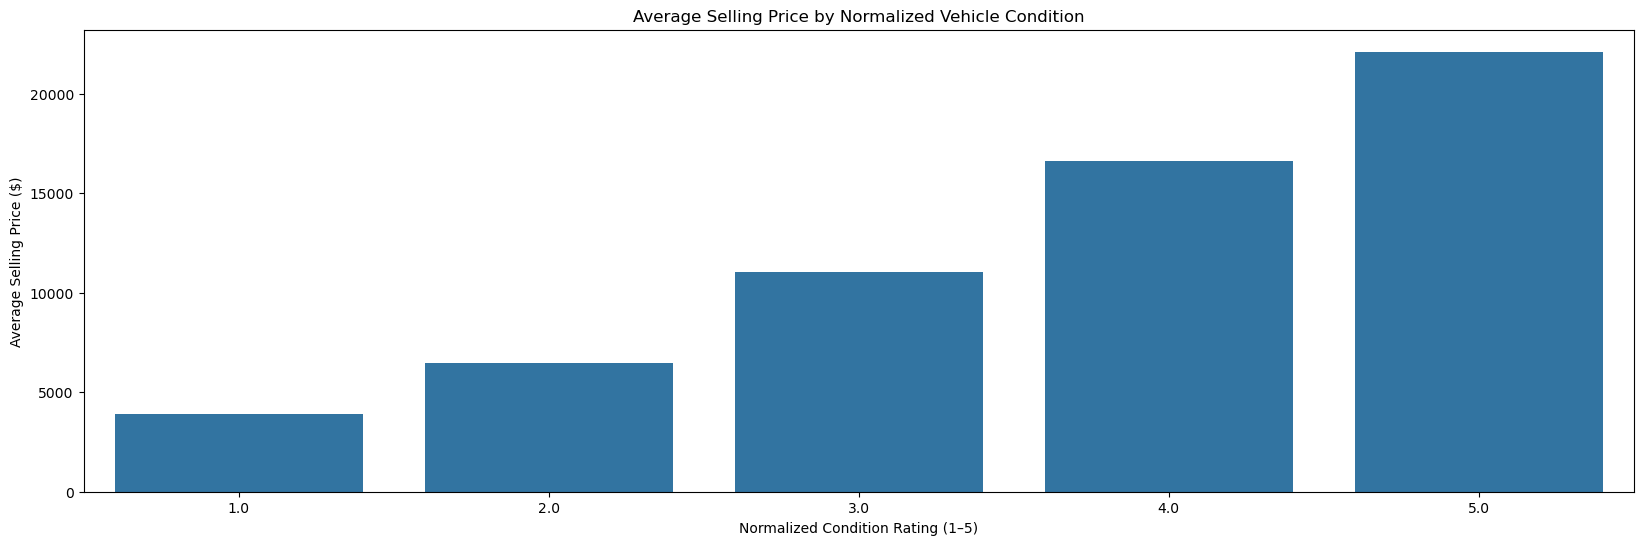

In [40]:
plt.figure(figsize=(20,6))
sb.barplot(data=data, x='condition', y='sellingprice', errorbar=None)
plt.title('Average Selling Price by Normalized Vehicle Condition')
plt.xlabel('Normalized Condition Rating (1–5)')
plt.ylabel('Average Selling Price ($)')
plt.show()

### Year

For the year column there isn't really anything to transform so I just checked that there wasn't any abnormal years in the column.

In [43]:
print(data['year'].value_counts().sort_index())

year
1982         2
1983         1
1984         5
1985        10
1986        11
1987         8
1988        11
1989        20
1990        49
1991        67
1992       132
1993       205
1994       392
1995       711
1996       851
1997      1546
1998      2149
1999      3363
2000      5227
2001      6468
2002      9715
2003     13281
2004     17342
2005     21394
2006     26913
2007     30845
2008     31502
2009     20594
2010     26485
2011     48548
2012    102315
2013     98168
2014     81070
2015      9415
Name: count, dtype: int64


### Make

For the make column I turned everything to lowercase and removed all spaces within the entries to eliminate any separation due to things like capitalization or double-spacing.

In [46]:
data['make'] = data['make'].str.lower().str.replace(' ', '')

Here we can see that some of the categories that belong together have been separated due to different spellings or formats, likely due to pulling data from different sources.

In [48]:
data['make'].value_counts()

make
ford             93997
chevrolet        60587
nissan           54017
toyota           39966
dodge            30955
honda            27351
hyundai          21836
bmw              20793
kia              18084
chrysler         17485
mercedes-benz    17141
jeep             15483
infiniti         15305
volkswagen       12583
lexus            11980
gmc              10638
mazda             8508
cadillac          7629
acura             5926
audi              5877
lincoln           5786
buick             5121
subaru            5103
ram               4574
pontiac           4524
mitsubishi        4257
volvo             3788
mini              3224
saturn            2841
mercury           2023
landrover         1891
scion             1687
jaguar            1420
porsche           1402
suzuki            1078
fiat               865
hummer             805
saab               484
smart              396
oldsmobile         384
isuzu              204
maserati           136
bentley            116
merced

After looking through the list, I manually replace wrongly formatted entries to re-group them with their correct names.

In [50]:
data['make'] = data['make'].replace({
    'mercedes': 'mercedes-benz',
    'mercedes-b': 'mercedes-benz',
    'mazdatk': 'mazda',
    'hyundaitk': 'hyundai',
    'chevtruck': 'chevrolet',
    'fordtk': 'ford',
    'dodgetk': 'dodge',
    'fordtruck': 'ford',
    'gmctruck': 'gmc',
    'vw': 'volkswagen'
})

Even after re-grouping some of our data, we still have some outliers such as the lotus or the four lamborghinis or the nine fiskers. So I dropped anything under 10 cars to try to reduce noise within the model as not many people own such cars. I chose 10 as the cutoff since I felt that the lowest count after this cleanup being 17 seems like a high enough number to not hurt the model too much but I might choose to increase the number depending on future model performance.

In [52]:
# drop anything under 10 to reduce noise in model
make_counts = data['make'].value_counts()
valid_makes = make_counts[make_counts >= 10].index

data = data[data['make'].isin(valid_makes)]

In [53]:
data['make'].value_counts()

make
ford             94001
chevrolet        60588
nissan           54017
toyota           39966
dodge            30956
honda            27351
hyundai          21837
bmw              20793
kia              18084
chrysler         17485
mercedes-benz    17213
jeep             15483
infiniti         15305
volkswagen       12607
lexus            11980
gmc              10649
mazda             8509
cadillac          7629
acura             5926
audi              5877
lincoln           5786
buick             5121
subaru            5103
ram               4574
pontiac           4524
mitsubishi        4257
volvo             3788
mini              3224
saturn            2841
mercury           2023
landrover         1891
scion             1687
jaguar            1420
porsche           1402
suzuki            1078
fiat               865
hummer             805
saab               484
smart              396
oldsmobile         384
isuzu              204
maserati           136
bentley            116
plymou

### Model

For the model column I did the same as I will with many of the categorical column, which is turn them to lowercase and remove spaces to group entries together.

In [56]:
data['model'] = data['model'].str.lower().str.replace(' ', '')

In [57]:
data['model'].value_counts()

model
altima                        19349
f-150                         14479
fusion                        12946
camry                         12549
escape                        11893
focus                         10399
accord                         9155
3series                        8204
impala                         7957
grandcaravan                   7941
explorer                       7781
civic                          7440
gsedan                         7417
corolla                        7360
malibu                         7146
sonata                         6914
maxima                         6611
silverado1500                  6362
cruze                          6349
elantra                        6265
townandcountry                 5994
edge                           5915
rogue                          5589
sentra                         5465
c-class                        5397
mustang                        4950
equinox                        4917
grandcherokee         

Again, I went through the list, from least to greatest and tried to stop obvious mispells or misformatted entries, such as the ones below that I manually fixed.

In [59]:
data['model'] = data['model'].replace({
    'ramvan': 'ram',
    'uplandr': 'uplander',
    'mountnr': 'mountaineer',
    'subrbn': 'suburban'
})

Again, I dropped anything under 10 count to try to reduce the noise in the model as there was a lot of entries below 10, also counts seem to quickly increase once they hit double digits.

In [61]:
# drop anything under 10 to reduce noise in model
model_counts = data['model'].value_counts()
valid_models = model_counts[model_counts >= 10].index

data = data[data['model'].isin(valid_models)]

In [62]:
data['model'].value_counts()

model
altima                    19349
f-150                     14479
fusion                    12946
camry                     12549
escape                    11893
focus                     10399
accord                     9155
3series                    8204
impala                     7957
grandcaravan               7941
explorer                   7781
civic                      7440
gsedan                     7417
corolla                    7360
malibu                     7146
sonata                     6914
maxima                     6611
silverado1500              6362
cruze                      6349
elantra                    6265
townandcountry             5994
edge                       5915
rogue                      5589
sentra                     5465
c-class                    5397
mustang                    4950
equinox                    4917
grandcherokee              4686
jetta                      4676
taurus                     4659
charger                    4542
op

### Trim

For the trim column, again, lowercase and remove spaces for grouping.

In [65]:
data['trim'] = data['trim'].str.lower().str.replace(' ', '')

In [66]:
data['trim'].value_counts()

trim
base                                          55618
se                                            43687
lx                                            20780
limited                                       18369
lt                                            16984
xlt                                           16745
ls                                            13528
le                                            12925
gls                                           12328
s                                             12255
2.5s                                          11212
sxt                                           11196
touring                                       11121
sel                                           10480
sport                                          9682
ex                                             9511
2.5                                            6908
slt                                            6012
sv                                             5700
ex-l   

There's a ridiculous number of trim entries so I decided to just drop anything under 10 and not manually check for errors as I believe there's enough data in the dataset to spare a few vehicles due to mispelled or misformatted trims.

In [68]:
# drop anything under 10 to reduce noise in model
trim_counts = data['trim'].value_counts()
valid_trims = trim_counts[trim_counts >= 10].index

data = data[data['trim'].isin(valid_trims)]

In [69]:
data['trim'].value_counts()

trim
base                                       55618
se                                         43687
lx                                         20780
limited                                    18369
lt                                         16984
xlt                                        16745
ls                                         13528
le                                         12925
gls                                        12328
s                                          12255
2.5s                                       11212
sxt                                        11196
touring                                    11121
sel                                        10480
sport                                       9682
ex                                          9511
2.5                                         6908
slt                                         6012
sv                                          5700
ex-l                                        5382
ltz            

### Body

Once again, lowercase and remove spaces for all.

In [72]:
data['body'] = data['body'].str.lower().str.replace(' ', '')

In [73]:
data['body'].value_counts()

body
sedan                     240487
suv                       143394
hatchback                  26098
minivan                    25453
coupe                      17536
crewcab                    16314
wagon                      15990
convertible                10335
supercrew                   9033
gsedan                      7413
supercab                    5291
regularcab                  4814
van                         4468
extendedcab                 4450
quadcab                     4095
e-seriesvan                 1823
doublecab                   1593
gcoupe                      1593
crewmaxcab                   556
kingcab                      525
gconvertible                 323
genesiscoupe                 294
accesscab                    285
koup                         180
clubcab                      178
ctscoupe                     158
megacab                      111
elantracoupe                 100
beetleconvertible             57
promastercargovan             51
xtrac

For the body column there actually wasn't really anything under 10 counts other than ramvan and that's clearly a van so I didn't need to cut down noise in this case. However, there is a lot of proprietary entries or brand entries such as 'gcoupe' or 'e-seriesvan' that can be grouped into more general body types, so I did a bit of reseach and categorized them into more general car body types, as you can see below.

In [75]:
# researched and generalized body types
data['body'] = data['body'].replace({    
    # sedan
    'gsedan': 'sedan',
    'navitgation': 'sedan', # some VW Jetta entries are shifted a bit

    # coupe
    'gcoupe': 'coupe',
    'elantracoupe': 'coupe',
    'g37coupe': 'coupe',
    'cts-vcoupe': 'coupe',
    'q60coupe': 'coupe',
    'genesiscoupe': 'coupe',
    'koup': 'coupe',
    'ctscoupe': 'coupe',

    # convertible
    'gconvertible': 'convertible',
    'g37convertible': 'convertible',
    'q60convertible': 'convertible',
    'beetleconvertible': 'convertible',
    'granturismoconvertible': 'convertible',

    # wagon
    'tsxsportwagon': 'wagon',
    'ctswagon': 'wagon',

    # van
    'ramvan': 'van',
    'e-seriesvan': 'van',
    'promastercargovan': 'van',

    # truck - crew cab
    # 4 full doors
    'crewcab': 'truck_crew',
    'supercrew': 'truck_crew',
    'crewmaxcab': 'truck_crew',
    'doublecab': 'truck_crew',
    'quadcab': 'truck_crew',
    'megacab': 'truck_crew',

    # truck - extended cab
    # 2 full doors and extra space w small back doors
    'supercab': 'truck_extended',
    'extendedcab': 'truck_extended',
    'accesscab': 'truck_extended',
    'xtracab': 'truck_extended',
    'kingcab': 'truck_extended',

    # truck - regular cab
    # 2 full doors
    'clubcab': 'truck_regular',
    'regularcab': 'truck_regular',
    'regular-cab': 'truck_regular',
})

In [76]:
data['body'].value_counts()

body
sedan             247900
suv               143394
truck_crew         31702
hatchback          26098
minivan            25453
coupe              19943
wagon              16040
convertible        10790
truck_extended     10595
van                 6343
truck_regular       5007
Name: count, dtype: int64

### Transmission

Lowercase and remove spaces.

In [79]:
data['transmission'] = data['transmission'].str.lower().str.replace(' ', '')

In [80]:
data['transmission'].value_counts()

transmission
automatic    465054
manual        16623
Name: count, dtype: int64

Again, this column was already pretty clean and I did a bit of cleaning some misinputed/shifted entries at the beginning so there wasn't much to clean up for noise and such.

In [82]:
data['transmission'].value_counts()

transmission
automatic    465054
manual        16623
Name: count, dtype: int64

### State

Lowercase and remove spaces.

In [85]:
data['state'] = data['state'].str.lower().str.replace(' ', '')

There wasn't much to fix here, mostly just checking there isn't any weird state entries.

In [87]:
data['state'].value_counts()

state
fl    81008
ca    70995
pa    52880
tx    44938
ga    33827
nj    27211
il    23108
nc    21159
oh    21092
tn    20612
mo    15728
mi    15221
nv    12343
va    11584
md    10744
wi     9646
mn     9257
az     8513
co     7632
wa     7178
ma     6481
ny     5552
in     4253
sc     4121
ne     3908
on     2950
pr     2626
la     2143
ms     1812
ut     1775
hi     1214
or     1127
qc     1089
ab      796
nm      161
ok       69
ns       46
al       25
Name: count, dtype: int64

### Odometer

For the odometer column there wasn't really much to do since these will probably vary wildly.

In [90]:
data['odometer'].value_counts()

odometer
1.0         1227
999999.0      67
10.0          29
21587.0       21
29137.0       18
            ... 
180866.0       1
110655.0       1
134305.0       1
207099.0       1
262065.0       1
Name: count, Length: 169253, dtype: int64

### Color

For color there wasn't much to do either, there was a good chunk of cars with '—' as the color, so I decided to replace them with NaNs to try to impute them later on.

In [93]:
data['color'].value_counts()

color
black        108363
white        103508
gray          81432
silver        81432
blue          49711
red           42427
—             24393
gold          10921
green         10786
beige          8898
burgundy       8741
brown          6599
orange         1995
purple         1515
off-white      1411
yellow         1219
charcoal        470
turquoise       224
pink             42
lime             15
Name: count, dtype: int64

In [94]:
data['color'] = data['color'].replace({    
    '—': np.nan
})

In [95]:
data['color'].value_counts()

color
black        108363
white        103508
gray          81432
silver        81432
blue          49711
red           42427
gold          10921
green         10786
beige          8898
burgundy       8741
brown          6599
orange         1995
purple         1515
off-white      1411
yellow         1219
charcoal        470
turquoise       224
pink             42
lime             15
Name: count, dtype: int64

### Interior

For interior the same thing happened as with the color column, so I also replaced the dashes with NaNs to try to impute them later on in the process.

In [98]:
data['interior'].value_counts()

interior
black        239638
gray         173400
beige         58216
tan           42753
—             16440
brown          8372
red            1273
silver         1069
blue           1021
off-white       478
purple          330
gold            312
white           235
green           227
burgundy        186
orange          133
yellow           19
Name: count, dtype: int64

In [99]:
data['interior'] = data['interior'].replace({    
    '—': np.nan
})

In [100]:
data['interior'].value_counts()

interior
black        239638
gray         173400
beige         58216
tan           42753
brown          8372
red            1273
silver         1069
blue           1021
off-white       478
purple          330
gold            312
white           235
green           227
burgundy        186
orange          133
yellow           19
Name: count, dtype: int64

### MMR

Nothing to really do with MMR.

In [103]:
data['mmr'].value_counts()

mmr
12500.0     1743
11600.0     1733
11650.0     1728
12150.0     1712
11850.0     1701
11300.0     1695
11750.0     1686
12350.0     1685
12700.0     1678
12200.0     1674
11250.0     1672
11950.0     1672
11050.0     1669
12750.0     1669
11700.0     1667
12650.0     1667
11400.0     1665
12050.0     1663
12450.0     1660
11350.0     1656
11500.0     1651
12400.0     1648
11900.0     1647
12000.0     1640
11800.0     1639
12600.0     1637
11150.0     1629
11550.0     1628
12800.0     1621
12250.0     1617
10950.0     1617
11450.0     1606
12100.0     1603
11200.0     1600
11100.0     1599
12300.0     1593
12850.0     1586
12950.0     1579
12550.0     1577
11000.0     1559
10900.0     1557
13000.0     1556
12900.0     1531
10850.0     1528
10800.0     1509
10650.0     1506
13050.0     1505
10750.0     1488
10500.0     1469
13100.0     1469
13400.0     1464
10700.0     1457
10600.0     1424
13250.0     1409
10150.0     1406
10050.0     1404
13450.0     1401
10200.0     1401
10450.0   

### Selling Price

Nothing to really do with selling price.

In [106]:
data['sellingprice'].value_counts()

sellingprice
11000.0     4394
12000.0     4382
13000.0     4282
10000.0     3979
14000.0     3855
11500.0     3827
12500.0     3673
9000.0      3607
10500.0     3476
15000.0     3351
9500.0      3311
11800.0     3247
13500.0     3242
16000.0     3076
8500.0      3067
12800.0     3036
11600.0     3033
8000.0      3031
12600.0     3013
11200.0     2968
11400.0     2949
17000.0     2919
12200.0     2860
10800.0     2849
18000.0     2822
7000.0      2817
14500.0     2806
4000.0      2748
10600.0     2728
13800.0     2724
6000.0      2706
10200.0     2695
13600.0     2693
12400.0     2660
13200.0     2647
11900.0     2580
7500.0      2577
11300.0     2568
20000.0     2548
10400.0     2546
13400.0     2544
3000.0      2543
5000.0      2532
9600.0      2528
3500.0      2525
11700.0     2524
9800.0      2520
19000.0     2519
16500.0     2498
10900.0     2487
11100.0     2479
9200.0      2447
12100.0     2431
9700.0      2429
10700.0     2426
10100.0     2425
12900.0     2416
12700.0     2413
2

### Sale Year

Nothing to really do with sale year, but we do see that basically all of the data comes from 2014 and 2015.

In [109]:
data['sale_year'].value_counts()

sale_year
2015.0    492237
2014.0     52575
Name: count, dtype: int64

## Feature Engineering

For this step, the feature I've been mentioning is the 'car_age' feature I'll be creating. When looking at useless columns to drop, I had the idea that I could calculate the age of the car by subtracting the sale year from the model year of the car, as the relative age of the car at the time of sale can affect the sale price. Especially since newer cars tend to be valued more as they're usually less used and come with newer features and such.

In [112]:
data['car_age'] = data['sale_year'] - data['year']

data = data.drop(columns=['sale_year'])

In [113]:
data['car_age'].value_counts()

car_age
 3.0     98776
 2.0     98746
 1.0     81839
 4.0     45681
 7.0     31068
 8.0     28936
 5.0     25376
 9.0     24602
 6.0     21577
 10.0    19616
 11.0    15865
 0.0     13941
 12.0    12249
 13.0     8896
 14.0     6059
 15.0     4052
 16.0     2660
 17.0     1703
 18.0     1188
 19.0      665
 20.0      516
 21.0      289
-1.0       201
 22.0      147
 23.0       89
 24.0       48
 25.0       27
Name: count, dtype: int64

In [114]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544824 entries, 0 to 558836
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          544824 non-null  int64  
 1   make          544824 non-null  object 
 2   model         544824 non-null  object 
 3   trim          544824 non-null  object 
 4   body          543265 non-null  object 
 5   transmission  481677 non-null  object 
 6   state         544824 non-null  object 
 7   condition     533483 non-null  float64
 8   odometer      544738 non-null  float64
 9   color         519709 non-null  object 
 10  interior      527662 non-null  object 
 11  mmr           544812 non-null  float64
 12  sellingprice  544812 non-null  float64
 13  car_age       544812 non-null  float64
dtypes: float64(5), int64(1), object(8)
memory usage: 62.4+ MB


## Handling Missing Data

First, I wanted to get a look at the amount of missing data and the percentage of the data missing.

In [117]:
missing_ratio = (data.isna().sum() / len(data)).sort_values(ascending=False)
missing_info = [f"{data.isna().sum()[col]}/{len(data)}" for col in missing_ratio.index]

missing = pd.DataFrame({
    'Missing (count/total)': missing_info,
    'Missing Ratio (%)': (missing_ratio * 100).round(2)
})

print(missing)

             Missing (count/total)  Missing Ratio (%)
transmission          63147/544824              11.59
color                 25115/544824               4.61
interior              17162/544824               3.15
condition             11341/544824               2.08
body                   1559/544824               0.29
odometer                 86/544824               0.02
mmr                      12/544824               0.00
sellingprice             12/544824               0.00
car_age                  12/544824               0.00
year                      0/544824               0.00
make                      0/544824               0.00
model                     0/544824               0.00
trim                      0/544824               0.00
state                     0/544824               0.00


To deal with the missing data, I wrote this function to impute missing data from a column using the mode from similar data by grouping based on selected features.

In [119]:
def impute_col(data, group_cols, target_col):
    mode_by_group = data.groupby(group_cols)[target_col].agg(
        lambda x: x.mode().iloc[0] if not x.mode().empty else np.nan
    )
    
    def imputer(row):
        if pd.isna(row[target_col]):
            try:
                key = tuple(row[col] for col in group_cols)
                return mode_by_group.loc[key]
            except:
                return np.nan
        return row[target_col]
        
    return data.apply(imputer, axis=1)

### Transmission

Transmission was the column missing the most data, missing about 11,59% of the data, which is a pretty significant amount given the total size of the dataset, so we're missing around 63,000 entries.

This is the pre-impute data count.

In [123]:
data['transmission'].value_counts()

transmission
automatic    465054
manual        16623
Name: count, dtype: int64

In [124]:
missing_ratio = (data['transmission'].isna().sum() / len(data))
missing_info = f"{data['transmission'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['transmission'])

print(missing)

             Missing (count/total)  Missing Ratio (%)
transmission          63147/544824              11.59


Here I use the impute function from earlier to impute the missing data based on the make, model, and trim, as they're likely to have the same transmission if they match all 3.

In [126]:
data['transmission'] = impute_col(data, ['make', 'model', 'trim'], 'transmission')

Here, in the post-impute count, we can see that both transmission count increase due to a successful impute.

In [128]:
data['transmission'].value_counts()

transmission
automatic    527948
manual        16808
Name: count, dtype: int64

Now we can see that we've gone from 11.59% of the data missing, to just about 0.01%. We're now only missing 68 entries versus the previous 63,000.

In [130]:
missing_ratio = (data['transmission'].isna().sum() / len(data))
missing_info = f"{data['transmission'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['transmission'])

print(missing)

             Missing (count/total)  Missing Ratio (%)
transmission             68/544824               0.01


Since we're only missing 68 entries out of 544,000 after imputing, I decided to simply drop these few vehicles with missing data as it's an insignificant amount that we can probably spare.

In [132]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['transmission'])
print("After:", len(data), "rows")

Before: 544824 rows
After: 544756 rows


### Color

Color was our second highest percentage of missing data, at 4.61%, which means we're missing around 25,000 entries.

In [135]:
data['color'].value_counts()

color
black        108340
white        103492
silver        81426
gray          81424
blue          49705
red           42422
gold          10920
green         10786
beige          8898
burgundy       8741
brown          6599
orange         1995
purple         1515
off-white      1411
yellow         1219
charcoal        470
turquoise       224
pink             42
lime             15
Name: count, dtype: int64

In [136]:
missing_ratio = (data['color'].isna().sum() / len(data))
missing_info = f"{data['color'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['color'])

print(missing)

      Missing (count/total)  Missing Ratio (%)
color          25112/544756               4.61


Again, I use the function to impute the data based on make, model, and trim, since while these may have varying colors, using the mode gives us the most common color, which is also probably the most likely color for these vehicles.

In [138]:
data['color'] = impute_col(data, ['make', 'model', 'trim'], 'color')

Now we see that after imputing, our missing data drops to just 1 single vehicle, which I will simply drop as we can spare just 1.

In [140]:
missing_ratio = (data['color'].isna().sum() / len(data))
missing_info = f"{data['color'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['color'])

print(missing)

      Missing (count/total)  Missing Ratio (%)
color              1/544756                0.0


In [141]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['color'])
print("After:", len(data), "rows")

Before: 544756 rows
After: 544755 rows


### Interior

Interior was our third highest percentage of missing data at 3.15%, which means we're missing around 17,000 entries

In [144]:
data['interior'].value_counts()

interior
black        239581
gray         173397
beige         58213
tan           42752
brown          8369
red            1273
silver         1069
blue           1021
off-white       478
purple          330
gold            312
white           235
green           227
burgundy        186
orange          133
yellow           19
Name: count, dtype: int64

In [145]:
missing_ratio = (data['interior'].isna().sum() / len(data))
missing_info = f"{data['interior'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['interior'])

print(missing)

         Missing (count/total)  Missing Ratio (%)
interior          17160/544755               3.15


Like with color, I will impute the data based on make, model, and trim, for the same reasons as with color.

In [147]:
data['interior'] = impute_col(data, ['make', 'model', 'trim'], 'interior')

After imputing, we can see that we go from 3.15% missing to just 6 entries missing, which I will also drop, as such a small amount will be negligible, like with color.

In [149]:
missing_ratio = (data['interior'].isna().sum() / len(data))
missing_info = f"{data['interior'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['interior'])

print(missing)

         Missing (count/total)  Missing Ratio (%)
interior              6/544755                0.0


In [150]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['interior'])
print("After:", len(data), "rows")

Before: 544755 rows
After: 544749 rows


### Condition

Condition was our fourth highest percentage of missing data, at 2.08%, which means we're missing around 11,000 entries.

In [153]:
data['condition'].value_counts()

condition
4.0    240780
3.0    120934
2.0    104470
5.0     59977
1.0      7251
Name: count, dtype: int64

In [154]:
missing_ratio = (data['condition'].isna().sum() / len(data))
missing_info = f"{data['condition'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['condition'])

print(missing)

          Missing (count/total)  Missing Ratio (%)
condition          11337/544749               2.08


In a similar method as with transmission, I impute the data using the function, except this time I use make, model, and odometer, as I think the odometer might be a more relevant feature to condition than the trim as more miles usually means more use and worse condition.

In [156]:
data['condition'] = impute_col(data, ['make', 'model', 'odometer'], 'condition')

In [157]:
data['condition'].value_counts()

condition
4.0    240867
3.0    120980
2.0    104585
5.0     59991
1.0      7279
Name: count, dtype: int64

After imputing, we can see that we only dropped to 2.03%, which means at least a few entries were successfully imputed, which is reasonable since odometer reader are more of a random number. However, make and model are not enough on their own to determine the condition of a car. Which is why I proceeded to impute the remaining missing data using my engineered feature 'car_age' instead of odometer, as older cars are likely to be in worse condition due to more use.

In [159]:
missing_ratio = (data['condition'].isna().sum() / len(data))
missing_info = f"{data['condition'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['condition'])

print(missing)

          Missing (count/total)  Missing Ratio (%)
condition          11047/544749               2.03


In [160]:
data['condition'] = impute_col(data, ['make', 'model', 'car_age'], 'condition')

Now we can see that after imputing using car age, we drop our missing data to 0.01% from 2.03%, now only missing 58 vehicles, which I will simply drop as it's a pretty insignificant amount that we can afford to spare due to our dataset size of 544,000.

In [162]:
missing_ratio = (data['condition'].isna().sum() / len(data))
missing_info = f"{data['condition'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['condition'])

print(missing)

          Missing (count/total)  Missing Ratio (%)
condition             58/544749               0.01


In [163]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['condition'])
print("After:", len(data), "rows")

Before: 544749 rows
After: 544691 rows


### Body

Body is our fifth highest percentage of missing data, however since we've dropped a few entries, we'll recheck the percentage of data missing again. Where we can see that we're now only missing around 0.27% of data, which is still about 1500 entries.

In [166]:
data['body'].value_counts()

body
sedan             247874
suv               143382
truck_crew         31699
hatchback          26093
minivan            25451
coupe              19937
wagon              16036
convertible        10785
truck_extended     10593
van                 6341
truck_regular       5007
Name: count, dtype: int64

In [167]:
missing_ratio = (data['body'].isna().sum() / len(data))
missing_info = f"{data['body'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['body'])

print(missing)

     Missing (count/total)  Missing Ratio (%)
body           1493/544691               0.27


Again, I will impute the body data using the make, model, and trim, since these will most likely have the same body type.

In [169]:
data['body'] = impute_col(data, ['make', 'model', 'trim'], 'body')

We're now down to 0.2%, which means we're still missing about 1000 entries so I will continue to impute again, except this time only using make and model.

In [171]:
missing_ratio = (data['body'].isna().sum() / len(data))
missing_info = f"{data['body'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['body'])

print(missing)

     Missing (count/total)  Missing Ratio (%)
body           1087/544691                0.2


In [172]:
data['body'] = impute_col(data, ['make', 'model'], 'body')

Now we've dropped down to 0.07%, or around 400 entries. While 400 is still more than I would want, I think we can safely drop them as imputing just using make would be inaccurate since brands make various types of vehicles so I will proceed to drop the remaining entries since 0.07 is still a relatively insignificant amount.

In [174]:
missing_ratio = (data['body'].isna().sum() / len(data))
missing_info = f"{data['body'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['body'])

print(missing)

     Missing (count/total)  Missing Ratio (%)
body            406/544691               0.07


In [175]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['body'])
print("After:", len(data), "rows")

Before: 544691 rows
After: 544285 rows


In [176]:
missing_ratio = (data['body'].isna().sum() / len(data))
missing_info = f"{data['body'].isna().sum()}/{len(data)}"

missing = pd.DataFrame({
    'Missing (count/total)': [missing_info],
    'Missing Ratio (%)': [round(missing_ratio * 100, 2)]
}, index=['body'])

print(missing)

     Missing (count/total)  Missing Ratio (%)
body              0/544285                0.0


### Odometer, MMR, Selling Price, and Car Age

Finally, odometer, mmr, selling price, and car age are our final columns with missing data. Odometer is the highest, at 0.02% or 85 entries. However, odometer readings aren't something I think we can accurately impute due to the nature of them, along with the other 3, they're all just missing 12 entries, none of these can really be imputed accurately. So I will continue to simply drop all of these as to not introduce unnecessary noise into the model.

In [179]:
missing_ratio = (data.isna().sum() / len(data)).sort_values(ascending=False)
missing_info = [f"{data.isna().sum()[col]}/{len(data)}" for col in missing_ratio.index]

missing = pd.DataFrame({
    'Missing (count/total)': missing_info,
    'Missing Ratio (%)': (missing_ratio * 100).round(2)
})

print(missing)

             Missing (count/total)  Missing Ratio (%)
odometer                 85/544285               0.02
mmr                      12/544285               0.00
sellingprice             12/544285               0.00
car_age                  12/544285               0.00
year                      0/544285               0.00
make                      0/544285               0.00
model                     0/544285               0.00
trim                      0/544285               0.00
body                      0/544285               0.00
transmission              0/544285               0.00
state                     0/544285               0.00
condition                 0/544285               0.00
color                     0/544285               0.00
interior                  0/544285               0.00


In [180]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['odometer'])
print("After:", len(data), "rows")

Before: 544285 rows
After: 544200 rows


In [181]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['mmr'])
print("After:", len(data), "rows")

Before: 544200 rows
After: 544188 rows


In [182]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['sellingprice'])
print("After:", len(data), "rows")

Before: 544188 rows
After: 544188 rows


In [183]:
print("Before:", len(data), "rows")
data = data.dropna(subset=['car_age'])
print("After:", len(data), "rows")

Before: 544188 rows
After: 544188 rows


Finally, all of our data is relatively clean and organized with no missing data.

In [185]:
missing_ratio = (data.isna().sum() / len(data)).sort_values(ascending=False)
missing_info = [f"{data.isna().sum()[col]}/{len(data)}" for col in missing_ratio.index]

missing = pd.DataFrame({
    'Missing (count/total)': missing_info,
    'Missing Ratio (%)': (missing_ratio * 100).round(2)
})

print(missing)

             Missing (count/total)  Missing Ratio (%)
year                      0/544188                0.0
make                      0/544188                0.0
model                     0/544188                0.0
trim                      0/544188                0.0
body                      0/544188                0.0
transmission              0/544188                0.0
state                     0/544188                0.0
condition                 0/544188                0.0
odometer                  0/544188                0.0
color                     0/544188                0.0
interior                  0/544188                0.0
mmr                       0/544188                0.0
sellingprice              0/544188                0.0
car_age                   0/544188                0.0


## Model Comparison Target Feature Removal

As mentioned earlier, here I remove the MMR feature from the main dataset, after it's been pre-processed and clean, so that the model can be trained without data leakage. A copy of the dataset with MMR still included is also made, to train an identical model and compare the performance between the two models.

In [188]:
dataMMR = data
data = data.drop(columns=['mmr'])

In [189]:
dataMMR.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544188 entries, 0 to 558836
Data columns (total 14 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          544188 non-null  int64  
 1   make          544188 non-null  object 
 2   model         544188 non-null  object 
 3   trim          544188 non-null  object 
 4   body          544188 non-null  object 
 5   transmission  544188 non-null  object 
 6   state         544188 non-null  object 
 7   condition     544188 non-null  float64
 8   odometer      544188 non-null  float64
 9   color         544188 non-null  object 
 10  interior      544188 non-null  object 
 11  mmr           544188 non-null  float64
 12  sellingprice  544188 non-null  float64
 13  car_age       544188 non-null  float64
dtypes: float64(5), int64(1), object(8)
memory usage: 62.3+ MB


## Feature Encoding

Since this dataset contains a lot of catergorical data being used to estimate the price of a vehicle we're going to have to create dummy variables so we're able to use this data properly in models. This will significantly blow up our data set from aroundf 61MB to around almost 1GB, however given the nature of a price predicting model, I think the size seems appropriate as there's a lot of variables that can affect the price of a car. Since I'm mostly going for accuracy, I will include all the columns we currently have and might consider reducing them based on model performance and accuracy later on.

In [192]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544188 entries, 0 to 558836
Data columns (total 13 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   year          544188 non-null  int64  
 1   make          544188 non-null  object 
 2   model         544188 non-null  object 
 3   trim          544188 non-null  object 
 4   body          544188 non-null  object 
 5   transmission  544188 non-null  object 
 6   state         544188 non-null  object 
 7   condition     544188 non-null  float64
 8   odometer      544188 non-null  float64
 9   color         544188 non-null  object 
 10  interior      544188 non-null  object 
 11  sellingprice  544188 non-null  float64
 12  car_age       544188 non-null  float64
dtypes: float64(4), int64(1), object(8)
memory usage: 58.1+ MB


In [193]:
data.head()

,year,make,model,trim,body,transmission,state,condition,odometer,color,interior,sellingprice,car_age
0,2015,kia,sorento,lx,suv,automatic,ca,5.0,16639.0,white,black,21500.0,-1.0
1,2015,kia,sorento,lx,suv,automatic,ca,5.0,9393.0,white,beige,21500.0,-1.0
2,2014,bmw,3series,328isulev,sedan,automatic,ca,4.0,1331.0,gray,black,30000.0,1.0
3,2015,volvo,s60,t5,sedan,automatic,ca,4.0,14282.0,white,black,27750.0,0.0
4,2014,bmw,6seriesgrancoupe,650i,sedan,automatic,ca,4.0,2641.0,gray,black,67000.0,0.0


In [194]:
dataMMR = pd.get_dummies(dataMMR, columns=['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior'], drop_first=True)

In [195]:
data = pd.get_dummies(data, columns=['make', 'model', 'trim', 'body', 'transmission', 'state', 'color', 'interior'], drop_first=True)

In [196]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544188 entries, 0 to 558836
Columns: 1822 entries, year to interior_yellow
dtypes: bool(1817), float64(4), int64(1)
memory usage: 967.9 MB


In [197]:
data.head()

,year,condition,odometer,sellingprice,car_age,make_astonmartin,make_audi,make_bentley,make_bmw,make_buick,...,interior_gray,interior_green,interior_off-white,interior_orange,interior_purple,interior_red,interior_silver,interior_tan,interior_white,interior_yellow
0,2015,5.0,16639.0,21500.0,-1.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2015,5.0,9393.0,21500.0,-1.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2014,4.0,1331.0,30000.0,1.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2015,4.0,14282.0,27750.0,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2014,4.0,2641.0,67000.0,0.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


# Modeling

For this section, I started with a linear regression. After running the model, I saw about 97% accuracy, which made me think something was wrong. I used the model’s coefficients and tried Ridge regression to address multicollinearity and check which features were most important. It turns out the top feature was the MMR column, which is an estimated price that came with the dataset. I originally left it in to help the model make more accurate predictions, but it looks like the model is relying too heavily on it. Because of that, I decided to remove the MMR column and will re-run the linear regression without it.

In [200]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 544188 entries, 0 to 558836
Columns: 1822 entries, year to interior_yellow
dtypes: bool(1817), float64(4), int64(1)
memory usage: 967.9 MB


In [201]:
data.head()

,year,condition,odometer,sellingprice,car_age,make_astonmartin,make_audi,make_bentley,make_bmw,make_buick,...,interior_gray,interior_green,interior_off-white,interior_orange,interior_purple,interior_red,interior_silver,interior_tan,interior_white,interior_yellow
0,2015,5.0,16639.0,21500.0,-1.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2015,5.0,9393.0,21500.0,-1.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
2,2014,4.0,1331.0,30000.0,1.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
3,2015,4.0,14282.0,27750.0,0.0,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,2014,4.0,2641.0,67000.0,0.0,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


## Models with MMR

### Linear Regression

Here, we drop the selling price from the main dataset and use it as X, since that's what we're predicting and we use selling price as the y. We then split the data into training and testing sets using a 80/20 split.

In [205]:
X = dataMMR.drop(columns='sellingprice')
y = dataMMR['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Since we're using Ridge to handle multicollinearity, and Ridge is sensitive to feature magnitude, we scale the data to prevent any issues with it.

In [207]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

We then fit the data into a linear regression.

In [209]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

After fitting the model, we check the feature importance by checking the coefficient of each feature. The bigger the value, the more it affects the model. Here, we can see the ridiculously high numbers, which is how we know that we have a multicollinearity issue.

In [211]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_,
    'abs_importance': abs(lr.coef_)
}).sort_values(by='abs_importance', ascending=False)

print(importance_df.head(10))

               feature   coefficient  abs_importance
578    model_slk-class -1.001984e+15    1.001984e+15
46          make_smart  8.202995e+14    8.202995e+14
533      model_s-class  7.008232e+14    7.008232e+14
293      model_g-class  6.513274e+14    6.513274e+14
1514       trim_slk350  6.080402e+14    6.080402e+14
496      model_r-class -5.343257e+14    5.343257e+14
309        model_ghost  4.954902e+14    4.954902e+14
42    make_rolls-royce -4.936100e+14    4.936100e+14
577     model_sl-class -4.684025e+14    4.684025e+14
11      make_chevrolet  4.613949e+14    4.613949e+14


We then continue to use Ridge to try to remedy the multicollinearity issue. So we fit the data using Ridge and re-check the coefficients for the feature importance and we see that MMR is the dominating feature by a large margin.

In [213]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_coef = pd.Series(ridge.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(ridge_coef.head(20))

mmr          8961.896684
condition     873.356078
car_age       644.947765
year          413.911907
state_ca      350.181754
state_fl      297.343858
state_ga      216.704221
state_tx      216.392220
state_pa      212.209681
state_tn      196.151983
state_nc      191.182194
state_il      188.531739
state_mo      158.119734
state_nv      152.158567
state_oh      135.006556
state_wa      127.431255
state_co      125.279243
state_az      119.756706
state_nj      115.570389
state_mn      112.652132
dtype: float64


Finally, we predict using Ridge and observe the results of the evaluation metrics. Here, we see that the R2 score is around 97%, which is extremely high and suggests that the model can explain almost all the variance of the price. However, due to the extremely high correlation we previously saw with the MMR column, we can pretty confidently say it's simply overfitting due to the accurate estimates in the MMR and heavily relying on that feature for determinig the prices.

In [215]:
y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 983.816958722756
Mean Squared Error: 2560361.3613165
Root Mean Squared Error 1600.1129214266412
R2 Score: 0.972031339621484


## Models without MMR

### Ridge Regression

Here, we follow the same steps for the linear regression, except with a dataset that does **not** include the MMR column, to avoid the overfitting of the data.

In [219]:
X = data.drop(columns='sellingprice')
y = data['sellingprice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [220]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [221]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

LinearRegression()

In [222]:
importance_df = pd.DataFrame({
    'feature': X.columns,
    'coefficient': lr.coef_,
    'abs_importance': abs(lr.coef_)
}).sort_values(by='abs_importance', ascending=False)

print(importance_df.head(10))

              feature   coefficient  abs_importance
367          model_jx -1.883309e+15    1.883309e+15
1245        trim_jx35  1.658453e+15    1.658453e+15
292     model_g-class  1.647903e+15    1.647903e+15
19        make_hummer  1.645199e+15    1.645199e+15
394     model_m-class -1.584591e+15    1.584591e+15
21      make_infiniti  1.522527e+15    1.522527e+15
15          make_ford  1.407302e+15    1.407302e+15
168   model_clk-class  1.392641e+15    1.392641e+15
495     model_r-class  1.227541e+15    1.227541e+15
7            make_bmw  1.217833e+15    1.217833e+15


Here we see that without the MMR column, the main feature affecting the price estimates is the year column at 4662.461191, meaning that as the year increases so does the price. The second feature is the odometer, at -2206.619306, which means that as the odometer reading increases, the price decreases. From this list, we can continue making observations about how the features contribute to the estimates given by the model in the same manner.

In [224]:
ridge = Ridge(alpha=1.0)
ridge.fit(X_train_scaled, y_train)

ridge_coef = pd.Series(ridge.coef_, index=X.columns).sort_values(key=abs, ascending=False)
print(ridge_coef.head(20))

year               4662.461191
odometer          -2206.619306
body_truck_crew    1200.506183
model_suburban     1146.478075
condition          1112.285523
body_sedan         -881.196205
trim_base          -838.779396
trim_2.5s          -829.584317
trim_se            -802.296824
model_focus        -757.482740
trim_1500ls        -742.864765
model_versa        -711.587597
model_911           697.515132
model_cruze        -694.728227
trim_ls            -679.053479
car_age             675.456590
model_xj-series    -660.335665
model_explorer      629.203420
model_tahoe         623.374822
trim_2.5           -613.205010
dtype: float64


Finally, we predict with Ridge and we see that we get an R2 score of 88.2%, which is a more realistic metric and although it's still pretty high accuracy, given the size of the dataset used it's still a realistic figure. The MAE shows that our predictions tend to be off by around 2,077 dollars. The RMSE shows that our predictions are off by about 3287 dollars but RMSE is sensitive to large prediction errors. The high MSE value suggests that while most predictions may be accurate, there is some predictions that have large errors present, given we're using a large dataset with a wide variety of cars, I think that's to be expected.

In [226]:
y_pred = ridge.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 2077.1016812784865
Mean Squared Error: 10802734.417126482
Root Mean Squared Error 3286.7513470182807
R2 Score: 0.8819939971611813


Here, I made a visualization of the Ridge regression with the actual price and predicted price plotted.

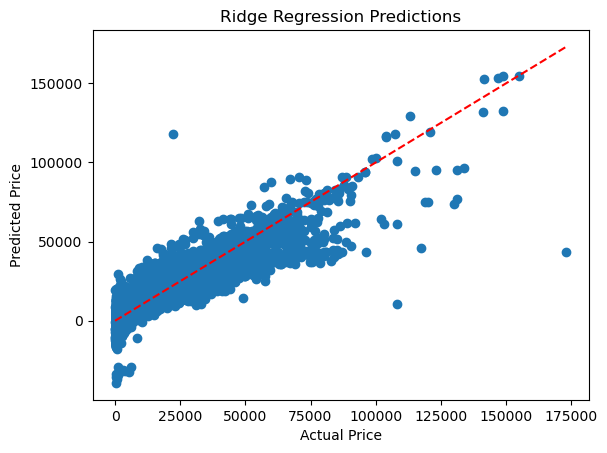

In [228]:
plt.scatter(y_test, ridge.predict(scaler.transform(X_test)))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Ridge Regression Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()

### Lasso Regression

Additionally, I fit a Lasso model rather than a Ridge one so that we can compare both models. This Lasso model has a max iteration of 10,000 since the default setting failed to converge, likely due to the complexity of the dataset.

In [231]:
lasso = Lasso(alpha=1.0, max_iter=10000)
lasso.fit(X_train_scaled, y_train)

Lasso(max_iter=10000)

Here, we see that the evaluation metrics for the Lasso model are pretty similar to the Ridge ones, which means both models are doing well and performing in roughly the same range. This tells us that either model could work for predicting car prices. That said, Lasso’s feature selection ability, where it pushes some coefficients to zero, could be helpful if we want a simpler model with fewer features. On the other hand, Ridge keeps all features but just shrinks their impact, which is useful if most features actually contribute useful info.

In [233]:
y_pred = lasso.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 2077.913729169111
Mean Squared Error: 10811397.361713141
Root Mean Squared Error 3288.068941143592
R2 Score: 0.8818993656147587


Here, I've also made another visualization of the regression results for Lasso, which looks almost identical to the one for Ridge.

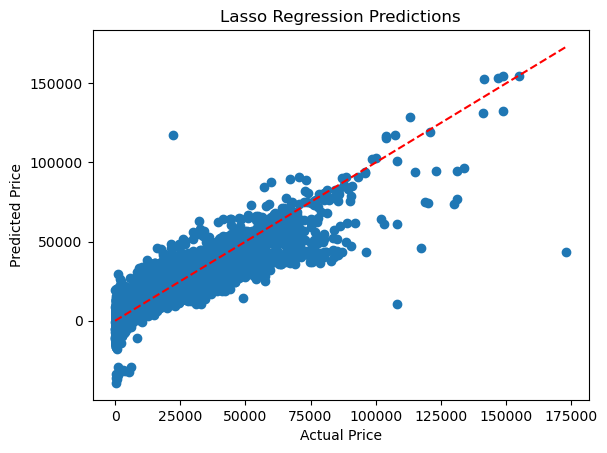

In [235]:
plt.scatter(y_test, lasso.predict(scaler.transform(X_test)))
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Lasso Regression Predictions")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.show()